In [23]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

**1. Environment Setup**

In [24]:
import numpy as np 
import pandas as pd 
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub

**2. Package Installation**

In [25]:
!pip install yfinance ripser persim --quiet

**3. Imports, Seeds & Device Setup**

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import warnings
warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)

Using device: cpu


**4. Data Ingestion (yfinance Download)**

In [27]:
import yfinance as yf

TICKER = "SPY"
START = "2005-01-01"
END = "2024-12-31"

raw = yf.download(TICKER, start=START, end=END, auto_adjust=True)
raw = raw[['Open', 'High', 'Low', 'Close', 'Volume']].dropna()
raw.columns = ['Open', 'High', 'Low', 'Close', 'Volume']
raw = raw.reset_index()
print(raw.shape)
raw.head()

[*********************100%***********************]  1 of 1 completed

(5032, 6)


,Date,Open,High,Low,Close,Volume
0,2005-01-03,82.024795,82.159752,80.904683,81.174591,55748000
1,2005-01-04,81.282602,81.336585,79.919572,80.182732,69167600
2,2005-01-05,80.121972,80.466106,79.622645,79.629395,65667300
3,2005-01-06,79.919531,80.398616,79.798073,80.034241,47814700
4,2005-01-07,80.277159,80.452600,79.710351,79.919533,55847700


**5. Technical Indicator Calculation & Preprocessing**

In [28]:
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(period).mean()
    avg_loss = loss.rolling(period).mean()
    rs = avg_gain / (avg_loss + 1e-9)
    return 100 - (100 / (1 + rs))

df = raw.copy()
df['log_return'] = np.log(df['Close']) - np.log(df['Close'].shift(1))
df['RSI'] = compute_rsi(df['Close'])
df['volatility'] = df['log_return'].rolling(20).std()
ema12 = df['Close'].ewm(span=12, adjust=False).mean()
ema26 = df['Close'].ewm(span=26, adjust=False).mean()
df['MACD'] = ema12 - ema26
df['volume_change'] = np.log(df['Volume'] + 1).diff()

df = df.dropna().reset_index(drop=True)
FEATURE_COLS = ['log_return', 'RSI', 'volatility', 'MACD', 'volume_change']

df.to_csv('preprocessed_data.csv', index=False)
print(df.shape)
df[['Date', 'Close'] + FEATURE_COLS].head()

(5012, 11)


,Date,Close,log_return,RSI,volatility,MACD,volume_change
0,2005-02-01,80.236664,0.006327,54.309262,0.006442,-0.322913,-0.052594
1,2005-02-02,80.479584,0.003023,54.146566,0.005860,-0.226293,0.051379
2,2005-02-03,80.270454,-0.002602,58.590238,0.005660,-0.164697,-0.071730
3,2005-02-04,81.127373,0.010619,61.775285,0.006025,-0.046204,0.024025
4,2005-02-07,81.019424,-0.001331,54.065445,0.006023,0.038549,-0.096738


**6. Sliding Window & Label Generation**

In [29]:
WINDOW = 60
STRIDE = 1
HORIZON = 1

def generate_windows(df, feature_cols, window=WINDOW, stride=STRIDE, horizon=HORIZON):
    values = df[feature_cols].values
    log_ret = df['log_return'].values
    close = df['Close'].values
    dates = df['Date'].values

    X_raw, X_logret, y, out_dates = [], [], [], []

    for i in range(0, len(df) - window - horizon, stride):
        w = values[i:i + window].copy()
        w = (w - w.mean(axis=0)) / (w.std(axis=0) + 1e-9)   # local z-score

        lr_window = log_ret[i:i + window].copy()
        target = 1 if close[i + window + horizon - 1] > close[i + window - 1] else 0

        X_raw.append(w)
        X_logret.append(lr_window)
        y.append(target)
        out_dates.append(dates[i + window - 1])

    return np.array(X_raw), np.array(X_logret), np.array(y), np.array(out_dates)

X_raw, X_logret, y, sample_dates = generate_windows(df, FEATURE_COLS)
print("Raw feature windows:", X_raw.shape)
print("Log-return windows (for TDA):", X_logret.shape)
print("Targets:", y.shape, " positive rate:", y.mean().round(3))

Raw feature windows: (4951, 60, 5)
Log-return windows (for TDA): (4951, 60)
Targets: (4951,)  positive rate: 0.551


**7. Takens Phase Space Embedding Estimation**

Optimal time delay tau = 3
Optimal embedding dimension d = 10


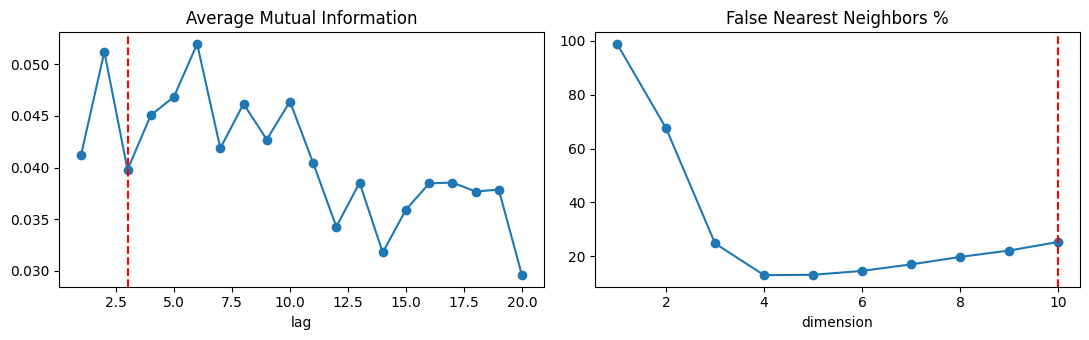

In [30]:
from sklearn.metrics import mutual_info_score
from scipy.spatial import cKDTree

def average_mutual_information(series, max_lag=20, bins=16):
    ami_vals = []
    for lag in range(1, max_lag + 1):
        x, yv = series[:-lag], series[lag:]
        c_xy = np.histogram2d(x, yv, bins=bins)[0]
        ami_vals.append(mutual_info_score(None, None, contingency=c_xy))
    return np.array(ami_vals)

def find_optimal_tau(series, max_lag=20):
    ami = average_mutual_information(series, max_lag)
    for i in range(1, len(ami) - 1):
        if ami[i] < ami[i - 1] and ami[i] < ami[i + 1]:
            return i + 1, ami
    return int(np.argmin(ami)) + 1, ami

def takens_embedding(series, tau, d):
    N = len(series)
    M = N - (d - 1) * tau
    if M <= 0:
        raise ValueError("Series too short for given tau/d")
    return np.array([series[i:i + (d - 1) * tau + 1:tau] for i in range(M)])

def false_nearest_neighbors(series, tau, max_dim=10, Rtol=15, Atol=2):
    N = len(series)
    Ra = np.std(series)
    fnn_percent = []
    for d in range(1, max_dim + 1):
        emb = takens_embedding(series, tau, d)
        M = len(emb)
        if M < 10:
            break
        tree = cKDTree(emb)
        dist, idx = tree.query(emb, k=2)
        nn_dist, nn_idx = dist[:, 1], idx[:, 1]

        false_count, valid = 0, 0
        for i in range(M):
            j = nn_idx[i]
            pt_i, pt_j = i + d * tau, j + d * tau
            if pt_i < N and pt_j < N and nn_dist[i] > 1e-10:
                dp1 = abs(series[pt_i] - series[pt_j])
                valid += 1
                ratio = dp1 / nn_dist[i]
                total_dist = np.sqrt(nn_dist[i] ** 2 + dp1 ** 2)
                if ratio > Rtol or total_dist / (Ra + 1e-12) > Atol:
                    false_count += 1
        pct = (false_count / valid * 100) if valid > 0 else 100.0
        fnn_percent.append(pct)
        if pct < 1.0 and d > 1:
            return d, fnn_percent
    return max_dim, fnn_percent

train_cutoff_for_params = int(len(df) * 0.7)
param_series = df['log_return'].values[:train_cutoff_for_params]

TAU, ami_curve = find_optimal_tau(param_series, max_lag=20)
EMBED_DIM, fnn_curve = false_nearest_neighbors(param_series, TAU, max_dim=10)
print(f"Optimal time delay tau = {TAU}")
print(f"Optimal embedding dimension d = {EMBED_DIM}")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].plot(range(1, len(ami_curve) + 1), ami_curve, marker='o')
axes[0].axvline(TAU, color='r', linestyle='--')
axes[0].set_title("Average Mutual Information"); axes[0].set_xlabel("lag")
axes[1].plot(range(1, len(fnn_curve) + 1), fnn_curve, marker='o')
axes[1].axvline(EMBED_DIM, color='r', linestyle='--')
axes[1].set_title("False Nearest Neighbors %"); axes[1].set_xlabel("dimension")
plt.tight_layout(); plt.show()

**8. Point Cloud Generation & Persistence Diagrams**

Number of diagrams: 4951
Example H0 shape: (33, 2)  H1 shape: (16, 2)


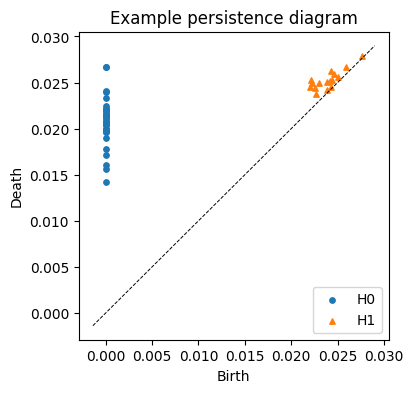

In [31]:
from ripser import ripser

# 1. Create Point Clouds using Takens embedding
point_clouds = [takens_embedding(series, TAU, EMBED_DIM) for series in X_logret]

# 2. Define Train/Val/Test Splits
n_samples = len(X_raw)
train_cutoff = int(n_samples * 0.7)
val_cutoff = int(n_samples * 0.85)

train_idx = np.arange(0, train_cutoff)
val_idx = np.arange(train_cutoff, val_cutoff)
test_idx = np.arange(val_cutoff, n_samples)

# 3. Compute Persistence Diagrams
def compute_persistence_diagrams(point_clouds, maxdim=1):
    return [ripser(pc, maxdim=maxdim)['dgms'] for pc in point_clouds]

diagrams = compute_persistence_diagrams(point_clouds, maxdim=1)
print("Number of diagrams:", len(diagrams))
print("Example H0 shape:", diagrams[0][0].shape, " H1 shape:", diagrams[0][1].shape)

# 4. Plot Example Persistence Diagram
h0, h1 = diagrams[0]
plt.figure(figsize=(4, 4))
finite_deaths = h0[h0[:, 1] < np.inf, 1]
plt.scatter(h0[:, 0], np.clip(h0[:, 1], 0, finite_deaths.max() if len(finite_deaths) else 1), label='H0', s=15)
if len(h1) > 0:
    plt.scatter(h1[:, 0], h1[:, 1], label='H1', s=15, marker='^')
lims = plt.xlim()
plt.plot(lims, lims, 'k--', linewidth=0.7)
plt.xlabel('Birth'); plt.ylabel('Death'); plt.legend(); plt.title('Example persistence diagram')
plt.show()

**9. TDA Feature Vectorization (Entropy & Persistence Images)**

In [32]:
import numpy as np
from persim import PersistenceImager
from scipy.ndimage import zoom

def persistence_entropy(dgm):
    dgm = dgm[np.isfinite(dgm[:, 1])]
    if len(dgm) == 0:
        return 0.0
    life = dgm[:, 1] - dgm[:, 0]
    life = life[life > 0]
    if len(life) == 0:
        return 0.0
    p = life / life.sum()
    return float(-np.sum(p * np.log(p + 1e-12)))


n_total = len(diagrams)
train_cut = int(n_total * 0.7)
train_h1 = [d[1] for d in diagrams[:train_cut] if len(d[1]) > 0]

all_births = np.concatenate([d[:, 0] for d in train_h1]) if train_h1 else np.array([0.0, 1.0])
all_deaths = np.concatenate([d[:, 1] for d in train_h1]) if train_h1 else np.array([0.0, 1.0])
all_pers = all_deaths - all_births

birth_span = float(all_births.max() - all_births.min()) + 1e-6
pers_span = float(all_pers.max() - all_pers.min()) + 1e-6

birth_range = (float(all_births.min()), float(all_births.max()) + 1e-6)
pers_range = (float(all_pers.min()), float(all_pers.max()) + 1e-6)

RAW_TARGET_BINS_PER_AXIS = 20
FINAL_IMAGE_SHAPE = (10, 10)

pixel_size = float(max(min(birth_span, pers_span) / RAW_TARGET_BINS_PER_AXIS, 1e-5))
pimgr = PersistenceImager(
    birth_range=birth_range,
    pers_range=pers_range,
    pixel_size=pixel_size
)

print("Raw persistence image resolution:", pimgr.resolution)

def vectorize_diagram(dgm_pair):
    h0, h1 = dgm_pair[0], dgm_pair[1]
    ent0, ent1 = persistence_entropy(h0), persistence_entropy(h1)

    if len(h1) > 0:
        raw_img = pimgr.transform(h1)
    else:
        raw_img = np.zeros(pimgr.resolution)

    zoom_factors = (
        FINAL_IMAGE_SHAPE[0] / raw_img.shape[0],
        FINAL_IMAGE_SHAPE[1] / raw_img.shape[1]
    )
    resized_img = zoom(raw_img, zoom_factors, order=1)

    return np.concatenate([[ent0, ent1], resized_img.flatten()])

tda_features = np.array([vectorize_diagram(dgm) for dgm in diagrams])

tda_mean = tda_features[:train_cut].mean(axis=0)
tda_std = tda_features[:train_cut].std(axis=0) + 1e-9
tda_features_scaled = (tda_features - tda_mean) / tda_std

print("TDA feature matrix:", tda_features.shape)
print("Scaled TDA feature matrix:", tda_features_scaled.shape)


TDA_SCALES = [30, 45, 60]

def compute_multiscale_tda_features(
    X_logret,
    scales=TDA_SCALES,
    tau=TAU,
    embed_dim=EMBED_DIM,
    vectorizer=vectorize_diagram
):
    feature_blocks = []

    for scale in scales:
        if scale <= (embed_dim - 1) * tau:
            raise ValueError(
                f"TDA scale {scale} is too short for tau={tau}, "
                f"embedding dimension={embed_dim}."
            )

        scale_features = []
        for series in X_logret:
            short_series = series[-scale:]
            pc = takens_embedding(short_series, tau, embed_dim)
            dgm = ripser(pc, maxdim=1)["dgms"]
            scale_features.append(vectorizer(dgm))

        feature_blocks.append(np.asarray(scale_features))

    return np.concatenate(feature_blocks, axis=1)

# Set False first if you want an exact apples-to-apples comparison with v2.0.
USE_MULTISCALE_TDA = True

if USE_MULTISCALE_TDA:
    tda_multiscale_raw = compute_multiscale_tda_features(X_logret)
    ms_train_cut = int(len(tda_multiscale_raw) * 0.7)
    ms_mean = tda_multiscale_raw[:ms_train_cut].mean(axis=0)
    ms_std = tda_multiscale_raw[:ms_train_cut].std(axis=0) + 1e-9
    tda_model_features = (tda_multiscale_raw - ms_mean) / ms_std
    print("Multi-scale TDA shape:", tda_model_features.shape)
else:
    tda_model_features = tda_features_scaled

print("Final TDA input shape:", tda_model_features.shape)


Raw persistence image resolution: (110, 20)
TDA feature matrix: (4951, 102)
Scaled TDA feature matrix: (4951, 102)
Multi-scale TDA shape: (4951, 306)
Final TDA input shape: (4951, 306)


**10. Topological Signal Analysis (Crash Periods Lead Time)**

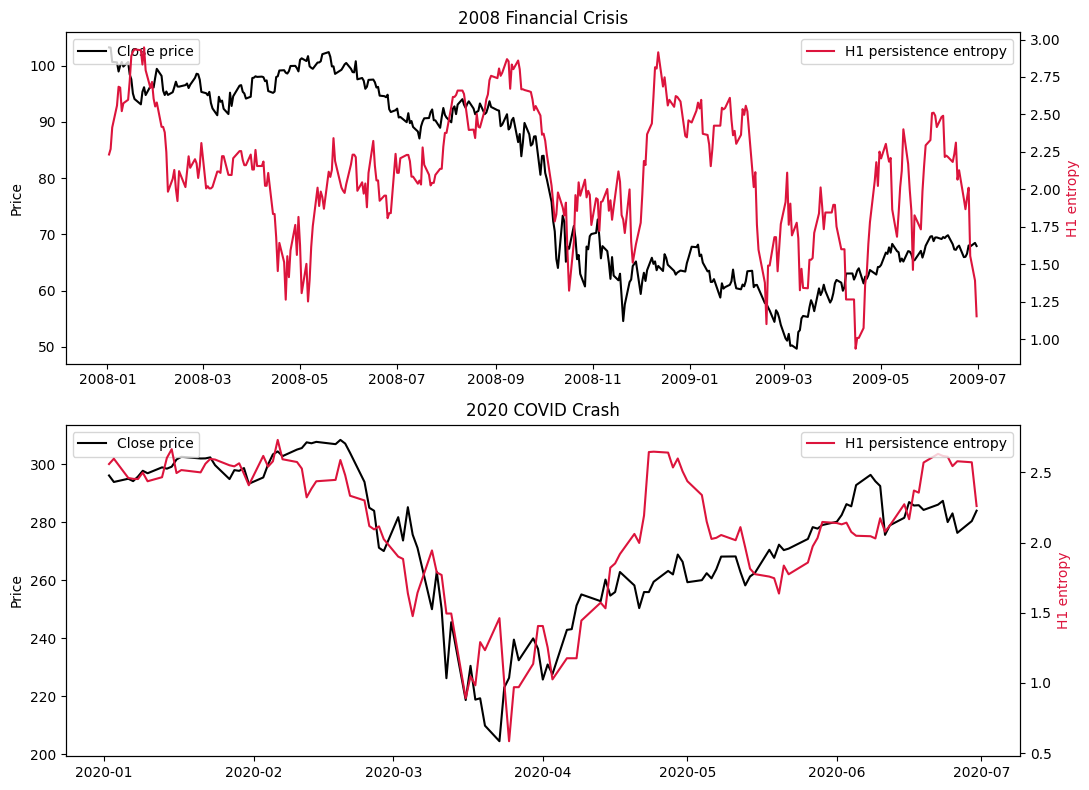

Look for entropy spikes/drops that lead the price decline.


In [33]:
crash_periods = {
    '2008 Financial Crisis': ('2008-01-01', '2009-06-30'),
    '2020 COVID Crash': ('2020-01-01', '2020-06-30'),
}

sample_dates_pd = pd.to_datetime(sample_dates)

df_indexed = df.copy()
df_indexed['Date'] = pd.to_datetime(df_indexed['Date'])
df_indexed = df_indexed.set_index('Date').sort_index()

close_at_window_end = df_indexed['Close'].reindex(sample_dates_pd, method='ffill').to_numpy()
ent1_series = tda_features[:, 1]

active_periods = {
    name: (start, end) for name, (start, end) in crash_periods.items()
    if ((sample_dates_pd >= pd.to_datetime(start)) & (sample_dates_pd <= pd.to_datetime(end))).sum() > 0
}

if not active_periods:
    print("None of the configured crash periods fall inside your date range.")
else:
    fig, axes = plt.subplots(len(active_periods), 1, figsize=(11, 4 * len(active_periods)))
    if len(active_periods) == 1:
        axes = [axes]
    for ax, (name, (start, end)) in zip(axes, active_periods.items()):
        start_dt, end_dt = pd.to_datetime(start), pd.to_datetime(end)
        mask = (sample_dates_pd >= start_dt) & (sample_dates_pd <= end_dt)
        dates_sub, price_sub, ent_sub = sample_dates_pd[mask], close_at_window_end[mask], ent1_series[mask]
        
        ax2 = ax.twinx()
        ax.plot(dates_sub, price_sub, color='black', label='Close price')
        ax2.plot(dates_sub, ent_sub, color='crimson', label='H1 persistence entropy')
        ax.set_title(name); ax.set_ylabel('Price'); ax2.set_ylabel('H1 entropy', color='crimson')
        ax.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.tight_layout(); plt.show()
    print("Look for entropy spikes/drops that lead the price decline.")

**11. PyTorch Dataset & DataLoader Construction**

In [34]:
class WindowDataset(Dataset):
    def __init__(self, X_raw, X_tda, y, idx):
        self.X_raw = torch.tensor(X_raw[idx], dtype=torch.float32)
        self.X_tda = torch.tensor(X_tda[idx], dtype=torch.float32)
        self.y = torch.tensor(y[idx], dtype=torch.float32)

    def __len__(self):
        return len(self.y)

    def __getitem__(self, i):
        return self.X_raw[i], self.X_tda[i], self.y[i]

BATCH_SIZE = 64

train_ds = WindowDataset(X_raw, tda_model_features, y, train_idx)
val_ds = WindowDataset(X_raw, tda_model_features, y, val_idx)
test_ds = WindowDataset(X_raw, tda_model_features, y, test_idx)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)


**12. Baseline LSTM Model Architecture & Training**

In [35]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, balanced_accuracy_score, matthews_corrcoef
)

def seed_everything(seed):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

class BaselineLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            n_features, hidden_size, num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 1)
        )

    def forward(self, x_raw, x_tda=None):
        _, (h_n, _) = self.lstm(x_raw)
        return self.head(h_n[-1]).squeeze(-1)

def train_model(
    model, train_loader, val_loader,
    epochs=40, lr=5e-4, patience=7, pos_weight=None,
    verbose=True
):
    model.to(DEVICE)
    opt = torch.optim.AdamW(
        model.parameters(), lr=lr, weight_decay=1e-4
    )

    if pos_weight is None:
        y_train = train_loader.dataset.y
        num_pos = (y_train == 1).sum().item()
        num_neg = (y_train == 0).sum().item()
        pos_weight = torch.tensor(
            [num_neg / (num_pos + 1e-8)], device=DEVICE
        )
    elif not isinstance(pos_weight, torch.Tensor):
        pos_weight = torch.tensor([pos_weight], device=DEVICE)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss = float("inf")
    best_state = None
    wait = 0
    history = {"train_loss": [], "val_loss": []}

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for x_raw, x_tda, yb in train_loader:
            x_raw = x_raw.to(DEVICE)
            x_tda = x_tda.to(DEVICE)
            yb = yb.to(DEVICE)

            opt.zero_grad()
            logits = model(x_raw, x_tda)
            loss = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for x_raw, x_tda, yb in val_loader:
                x_raw = x_raw.to(DEVICE)
                x_tda = x_tda.to(DEVICE)
                yb = yb.to(DEVICE)

                logits = model(x_raw, x_tda)
                val_losses.append(loss_fn(logits, yb).item())

        tr_loss = float(np.mean(train_losses))
        vl_loss = float(np.mean(val_losses))
        history["train_loss"].append(tr_loss)
        history["val_loss"].append(vl_loss)

        if verbose:
            print(
                f"Epoch {epoch+1:02d} | "
                f"Train Loss={tr_loss:.4f} | Val Loss={vl_loss:.4f}"
            )

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in model.state_dict().items()
            }
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    return model, history

seed_everything(SEED)
baseline_model = BaselineLSTM(n_features=X_raw.shape[-1])
baseline_model, baseline_history = train_model(
    baseline_model, train_loader, val_loader
)


Epoch 01 | Train Loss=0.6261 | Val Loss=0.6240
Epoch 02 | Train Loss=0.6244 | Val Loss=0.6223
Epoch 03 | Train Loss=0.6237 | Val Loss=0.6214
Epoch 04 | Train Loss=0.6244 | Val Loss=0.6209
Epoch 05 | Train Loss=0.6235 | Val Loss=0.6214
Epoch 06 | Train Loss=0.6237 | Val Loss=0.6212
Epoch 07 | Train Loss=0.6244 | Val Loss=0.6214
Epoch 08 | Train Loss=0.6235 | Val Loss=0.6217
Epoch 09 | Train Loss=0.6238 | Val Loss=0.6216
Epoch 10 | Train Loss=0.6229 | Val Loss=0.6217
Epoch 11 | Train Loss=0.6228 | Val Loss=0.6223
Early stopping at epoch 11.


**13. Improved Hybrid LSTM + TDA (Gated Fusion)**


In [36]:
# --- Section 13, first cell: Baseline LSTM ---

class BaselineLSTM(nn.Module):
    def __init__(self, n_features, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden_size, num_layers=num_layers,
                             batch_first=True, dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 16), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(16, 1)
        )
    def forward(self, x_raw, x_tda=None):
        out, (h_n, c_n) = self.lstm(x_raw)
        return self.head(h_n[-1]).squeeze(-1)

def train_model(model, train_loader, val_loader, epochs=40, lr=5e-4, patience=7,
                 pos_weight=None, verbose=True):
    model.to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)

    if pos_weight is None:
        y_train = train_loader.dataset.y
        num_pos = (y_train == 1).sum().item()
        num_neg = (y_train == 0).sum().item()
        pos_weight = torch.tensor([num_neg / (num_pos + 1e-8)], device=DEVICE)
    elif not isinstance(pos_weight, torch.Tensor):
        pos_weight = torch.tensor([pos_weight], device=DEVICE)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    best_val_loss, best_state, wait = float('inf'), None, 0
    history = {'train_loss': [], 'val_loss': []}

    for epoch in range(epochs):
        model.train()
        train_losses = []
        train_preds, train_true = [], []
        for x_raw, x_tda, yb in train_loader:
            x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            logits = model(x_raw, x_tda)
            loss = loss_fn(logits, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            opt.step()
            train_losses.append(loss.item())
            train_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
            train_true.extend(yb.cpu().numpy())

        model.eval()
        val_losses = []
        val_preds, val_true = [], []
        with torch.no_grad():
            for x_raw, x_tda, yb in val_loader:
                x_raw, x_tda, yb = x_raw.to(DEVICE), x_tda.to(DEVICE), yb.to(DEVICE)
                logits = model(x_raw, x_tda)
                val_losses.append(loss_fn(logits, yb).item())
                val_preds.extend((torch.sigmoid(logits) > 0.5).long().cpu().numpy())
                val_true.extend(yb.cpu().numpy())

        tr_loss, vl_loss = np.mean(train_losses), np.mean(val_losses)
        history['train_loss'].append(tr_loss)
        history['val_loss'].append(vl_loss)

        if verbose:
            pos_rate_tr = np.mean(train_preds)
            pos_rate_vl = np.mean(val_preds)
            print(f"Epoch {epoch+1:02d} | Train Loss={tr_loss:.4f} (PosPred={pos_rate_tr:.2f}) "
                  f"| Val Loss={vl_loss:.4f} (PosPred={pos_rate_vl:.2f})")

        if vl_loss < best_val_loss:
            best_val_loss = vl_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                if verbose:
                    print(f"Early stopping triggered at epoch {epoch+1}.")
                break

    model.load_state_dict(best_state)
    return model, history


seed_everything(SEED)

baseline_model = BaselineLSTM(n_features=X_raw.shape[-1])
baseline_model, baseline_history = train_model(baseline_model, train_loader, val_loader)

Epoch 01 | Train Loss=0.6261 (PosPred=0.00) | Val Loss=0.6240 (PosPred=0.00)
Epoch 02 | Train Loss=0.6244 (PosPred=0.07) | Val Loss=0.6223 (PosPred=0.05)
Epoch 03 | Train Loss=0.6237 (PosPred=0.24) | Val Loss=0.6214 (PosPred=0.19)
Epoch 04 | Train Loss=0.6244 (PosPred=0.44) | Val Loss=0.6209 (PosPred=0.45)
Epoch 05 | Train Loss=0.6235 (PosPred=0.44) | Val Loss=0.6214 (PosPred=0.36)
Epoch 06 | Train Loss=0.6237 (PosPred=0.35) | Val Loss=0.6212 (PosPred=0.46)
Epoch 07 | Train Loss=0.6244 (PosPred=0.51) | Val Loss=0.6214 (PosPred=0.47)
Epoch 08 | Train Loss=0.6235 (PosPred=0.39) | Val Loss=0.6217 (PosPred=0.36)
Epoch 09 | Train Loss=0.6238 (PosPred=0.47) | Val Loss=0.6216 (PosPred=0.44)
Epoch 10 | Train Loss=0.6229 (PosPred=0.46) | Val Loss=0.6217 (PosPred=0.46)
Epoch 11 | Train Loss=0.6228 (PosPred=0.46) | Val Loss=0.6223 (PosPred=0.40)
Early stopping triggered at epoch 11.


In [37]:
# --- Hybrid Model: LSTM + TDA with Gated Fusion ---

class GatedHybridModel(nn.Module):
    """
    Raw branch:
        60 x 5 financial sequence -> LSTM -> temporal representation

    TDA branch:
        TDA vector -> MLP encoder -> topological representation

    Fusion:
        learned gate decides how much to rely on each representation.
    """
    def __init__(
        self,
        n_features,
        tda_dim,
        hidden_size=32,
        tda_hidden=32,
        fusion_hidden=32,
        dropout=0.2
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            n_features, hidden_size, batch_first=True
        )

        self.tda_encoder = nn.Sequential(
            nn.Linear(tda_dim, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, tda_hidden),
            nn.ReLU()
        )

        # Project both branches to the same dimension.
        fusion_dim = min(hidden_size, tda_hidden)

        self.raw_proj = nn.Linear(hidden_size, fusion_dim)
        self.tda_proj = nn.Linear(tda_hidden, fusion_dim)

        # The gate is data-dependent:
        # gate ~ 1 -> rely more on temporal representation
        # gate ~ 0 -> rely more on TDA representation
        self.gate = nn.Sequential(
            nn.Linear(fusion_dim * 2, fusion_dim),
            nn.ReLU(),
            nn.Linear(fusion_dim, fusion_dim),
            nn.Sigmoid()
        )

        self.fusion_head = nn.Sequential(
            nn.Linear(fusion_dim, fusion_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(fusion_hidden, 1)
        )

    def forward(self, x_raw, x_tda, return_gate=False):
        _, (h_n, _) = self.lstm(x_raw)
        raw_repr = h_n[-1]

        tda_repr = self.tda_encoder(x_tda)

        raw_repr = self.raw_proj(raw_repr)
        tda_repr = self.tda_proj(tda_repr)

        combined = torch.cat([raw_repr, tda_repr], dim=-1)
        gate = self.gate(combined)

        fused = gate * raw_repr + (1.0 - gate) * tda_repr
        logits = self.fusion_head(fused).squeeze(-1)

        if return_gate:
            return logits, gate
        return logits


seed_everything(SEED)
hybrid_model = GatedHybridModel(
    n_features=X_raw.shape[-1],
    tda_dim=tda_model_features.shape[-1]
)
hybrid_model, hybrid_history = train_model(
    hybrid_model, train_loader, val_loader
)


Epoch 01 | Train Loss=0.6251 (PosPred=0.86) | Val Loss=0.6212 (PosPred=0.53)
Epoch 02 | Train Loss=0.6239 (PosPred=0.33) | Val Loss=0.6211 (PosPred=0.48)
Epoch 03 | Train Loss=0.6243 (PosPred=0.54) | Val Loss=0.6212 (PosPred=0.67)
Epoch 04 | Train Loss=0.6234 (PosPred=0.41) | Val Loss=0.6210 (PosPred=0.39)
Epoch 05 | Train Loss=0.6236 (PosPred=0.51) | Val Loss=0.6213 (PosPred=0.35)
Epoch 06 | Train Loss=0.6242 (PosPred=0.39) | Val Loss=0.6207 (PosPred=0.59)
Epoch 07 | Train Loss=0.6238 (PosPred=0.62) | Val Loss=0.6212 (PosPred=0.44)
Epoch 08 | Train Loss=0.6238 (PosPred=0.54) | Val Loss=0.6213 (PosPred=0.38)
Epoch 09 | Train Loss=0.6232 (PosPred=0.44) | Val Loss=0.6214 (PosPred=0.38)
Epoch 10 | Train Loss=0.6236 (PosPred=0.58) | Val Loss=0.6213 (PosPred=0.45)
Epoch 11 | Train Loss=0.6235 (PosPred=0.54) | Val Loss=0.6215 (PosPred=0.39)
Epoch 12 | Train Loss=0.6233 (PosPred=0.48) | Val Loss=0.6214 (PosPred=0.48)
Epoch 13 | Train Loss=0.6226 (PosPred=0.43) | Val Loss=0.6221 (PosPred=0.47)

**14. Financial Strategy Backtesting & Performance Evaluation**

                               accuracy  precision  recall      f1  roc_auc  \
Baseline LSTM                    0.4980     0.5329  0.4315  0.4769   0.5015   
Improved Hybrid (Gated + TDA)    0.4993     0.5217  0.6726  0.5876   0.4650   

                               balanced_accuracy     mcc  sharpe  sortino  \
Baseline LSTM                             0.5023  0.0046  0.1736   0.1595   
Improved Hybrid (Gated + TDA)             0.4882 -0.0254  0.2456   0.2839   

                               annualized_return  max_drawdown  calmar  \
Baseline LSTM                              0.022       -0.2341  0.0942   
Improved Hybrid (Gated + TDA)              0.038       -0.2360  0.1608   

                               win_rate  n_trades  cumulative_return  
Baseline LSTM                    0.2288       147             0.0664  
Improved Hybrid (Gated + TDA)    0.3567       121             0.1161  

=== Transaction-Cost Sensitivity ===
   cost_bps  cumulative_return  sharpe  max_drawdown  n_

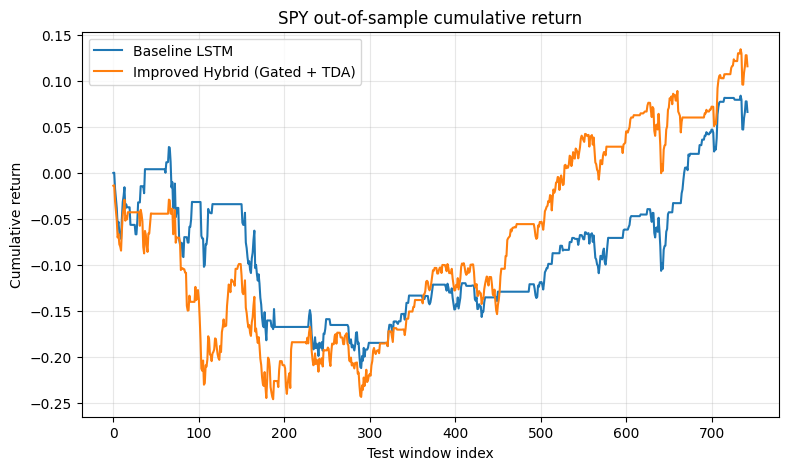

In [38]:
# --- financial evaluation ---

def get_predictions(model, loader):
    model.eval()
    probs, targets = [], []

    with torch.no_grad():
        for x_raw, x_tda, yb in loader:
            x_raw = x_raw.to(DEVICE)
            x_tda = x_tda.to(DEVICE)

            logits = model(x_raw, x_tda)
            probs.append(torch.sigmoid(logits).cpu().numpy())
            targets.append(yb.numpy())

    return np.concatenate(probs), np.concatenate(targets)

def evaluate_strategy(
    probs, targets, test_idx, log_returns_full,
    threshold=0.5, cost_bps=1.0
):
    preds = (probs > threshold).astype(int)
    accuracy = accuracy_score(targets, preds)
    precision = precision_score(targets, preds, zero_division=0)
    recall = recall_score(targets, preds, zero_division=0)
    f1 = f1_score(targets, preds, zero_division=0)
    balanced_acc = balanced_accuracy_score(targets, preds)
    mcc = matthews_corrcoef(targets, preds)

    if len(np.unique(targets)) == 2:
        auc = roc_auc_score(targets, probs)
    else:
        auc = np.nan

    realized = log_returns_full[test_idx]

    position = np.where(preds == 1, 1.0, 0.0)
    turnover = np.abs(np.diff(np.concatenate([[0.0], position])))
    cost = turnover * (cost_bps / 10000.0)

    strat_returns = position * realized - cost

    # Since realized is a log return, use exp(cumulative log return)-1.
    cumulative_log = np.cumsum(strat_returns)
    cum_returns = np.exp(cumulative_log) - 1.0

    mean_ret = strat_returns.mean()
    std_ret = strat_returns.std() + 1e-12
    sharpe = (mean_ret / std_ret) * np.sqrt(252)

    downside = strat_returns[strat_returns < 0]
    downside_std = downside.std() + 1e-12 if len(downside) else 1e-12
    sortino = (mean_ret / downside_std) * np.sqrt(252)

    running_max = np.maximum.accumulate(1.0 + cum_returns)
    drawdown = (1.0 + cum_returns) / running_max - 1.0
    mdd = float(drawdown.min())

    annualized_return = (
        np.exp(strat_returns.mean() * 252) - 1.0
    )

    calmar = (
        annualized_return / abs(mdd)
        if abs(mdd) > 1e-12 else np.nan
    )

    win_rate = float(np.mean(strat_returns > 0))
    n_trades = int(np.sum(turnover > 0))

    return {
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "roc_auc": float(auc),
        "balanced_accuracy": float(balanced_acc),
        "mcc": float(mcc),
        "sharpe": float(sharpe),
        "sortino": float(sortino),
        "annualized_return": float(annualized_return),
        "max_drawdown": mdd,
        "calmar": float(calmar),
        "win_rate": win_rate,
        "n_trades": n_trades,
        "cumulative_return": float(cum_returns[-1]),
    }, cum_returns

close_full = df["Close"].values

realized_returns_all = np.array([
    np.log(close_full[i + WINDOW + HORIZON - 1])
    - np.log(close_full[i + WINDOW - 1])
    for i in range(0, len(df) - WINDOW - HORIZON, STRIDE)
])

assert len(realized_returns_all) == len(y)

baseline_probs, baseline_targets = get_predictions(
    baseline_model, test_loader
)
hybrid_probs, hybrid_targets = get_predictions(
    hybrid_model, test_loader
)

baseline_metrics, baseline_cum = evaluate_strategy(
    baseline_probs, baseline_targets, test_idx, realized_returns_all
)
hybrid_metrics, hybrid_cum = evaluate_strategy(
    hybrid_probs, hybrid_targets, test_idx, realized_returns_all
)

comparison = pd.DataFrame(
    [baseline_metrics, hybrid_metrics],
    index=["Baseline LSTM", "Improved Hybrid (Gated + TDA)"]
)

print(comparison.round(4))

# -------------------------------------------------------------------------
# Transaction-cost sensitivity
# -------------------------------------------------------------------------
cost_results = []

for cost_bps in [0, 1, 5, 10, 20]:
    m, _ = evaluate_strategy(
        hybrid_probs, hybrid_targets, test_idx,
        realized_returns_all, cost_bps=cost_bps
    )
    cost_results.append({
        "cost_bps": cost_bps,
        "cumulative_return": m["cumulative_return"],
        "sharpe": m["sharpe"],
        "max_drawdown": m["max_drawdown"],
        "n_trades": m["n_trades"]
    })

cost_df = pd.DataFrame(cost_results)
print("\n=== Transaction-Cost Sensitivity ===")
print(cost_df.round(4))

plt.figure(figsize=(9, 5))
plt.plot(baseline_cum, label="Baseline LSTM")
plt.plot(hybrid_cum, label="Improved Hybrid (Gated + TDA)")
plt.xlabel("Test window index")
plt.ylabel("Cumulative return")
plt.title(f"{TICKER} out-of-sample cumulative return")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


**15. Ablation Study**

### Ablation interpretation

The labels are deliberately explicit:

- **Raw-only** = LSTM using conventional sequence features.
- **TDA-only** = MLP using TDA features without the LSTM branch.
- **LSTM + H0** = LSTM plus H0 entropy.
- **LSTM + H1 entropy** = LSTM plus H1 entropy.
- **LSTM + H1 image + entropy** = LSTM plus H1 persistence-image and entropy features.
- **LSTM + all TDA** = LSTM plus the complete single-scale TDA vector.




In [39]:
# --- ablation study ---

ABLATION_EPOCHS = 40
ABLATION_LR = 5e-4
ABLATION_PATIENCE = 7


tda_h0_scaled = tda_features_scaled[:, :1]
tda_h1_scaled = tda_features_scaled[:, 1:2]
tda_h1_pi_scaled = tda_features_scaled[:, 1:]

ablation_configs = {
    "Raw-only": {
        "kind": "raw",
        "tda_data": np.zeros((len(X_raw), 1)),
        "dim": 1
    },
    "TDA-only": {
        "kind": "tda",
        "tda_data": tda_features_scaled,
        "dim": tda_features_scaled.shape[1]
    },
    "LSTM + H0": {
        "kind": "hybrid",
        "tda_data": tda_h0_scaled,
        "dim": tda_h0_scaled.shape[1]
    },
    "LSTM + H1 entropy": {
        "kind": "hybrid",
        "tda_data": tda_h1_scaled,
        "dim": tda_h1_scaled.shape[1]
    },
    "LSTM + H1 image + entropy": {
        "kind": "hybrid",
        "tda_data": tda_h1_pi_scaled,
        "dim": tda_h1_pi_scaled.shape[1]
    },
    "LSTM + all TDA (single-scale)": {
        "kind": "hybrid",
        "tda_data": tda_features_scaled,
        "dim": tda_features_scaled.shape[1]
    },
    
    "LSTM + all TDA (multi-scale)": {
        "kind": "hybrid",
        "tda_data": tda_model_features,
        "dim": tda_model_features.shape[1]
    }
}

class TDAOnlyModel(nn.Module):
    def __init__(self, tda_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(tda_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x_raw, x_tda):
        return self.net(x_tda).squeeze(-1)

ablation_results = {}

for name, cfg in ablation_configs.items():
    print(f"\n--- Running Ablation: {name} ---")

    seed_everything(SEED)

    tr_ds = WindowDataset(X_raw, cfg["tda_data"], y, train_idx)
    vl_ds = WindowDataset(X_raw, cfg["tda_data"], y, val_idx)
    ts_ds = WindowDataset(X_raw, cfg["tda_data"], y, test_idx)

    tr_loader = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True)
    vl_loader = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False)
    ts_loader = DataLoader(ts_ds, batch_size=BATCH_SIZE, shuffle=False)

    if cfg["kind"] == "raw":
        model = BaselineLSTM(n_features=X_raw.shape[-1])
    elif cfg["kind"] == "tda":
        model = TDAOnlyModel(tda_dim=cfg["dim"])
    else:
        # Use the same gated architecture for every hybrid ablation.
        model = GatedHybridModel(n_features=X_raw.shape[-1], tda_dim=cfg["dim"])

    model, _ = train_model(
        model, tr_loader, vl_loader,
        epochs=ABLATION_EPOCHS, lr=ABLATION_LR, patience=ABLATION_PATIENCE,
        verbose=False
    )

    probs, targets = get_predictions(model, ts_loader)
    metrics, _ = evaluate_strategy(probs, targets, test_idx, realized_returns_all)
    ablation_results[name] = metrics

ablation_df = pd.DataFrame(ablation_results).T

print("\n=== Corrected Ablation Study ===")
print(ablation_df.round(4))


--- Running Ablation: Raw-only ---

--- Running Ablation: TDA-only ---

--- Running Ablation: LSTM + H0 ---

--- Running Ablation: LSTM + H1 entropy ---

--- Running Ablation: LSTM + H1 image + entropy ---

--- Running Ablation: LSTM + all TDA (single-scale) ---

--- Running Ablation: LSTM + all TDA (multi-scale) ---

=== Corrected Ablation Study ===
                               accuracy  precision  recall      f1  roc_auc  \
Raw-only                         0.4980     0.5329  0.4315  0.4769   0.5015   
TDA-only                         0.4805     0.5165  0.3173  0.3931   0.5230   
LSTM + H0                        0.5249     0.5373  0.7487  0.6257   0.5062   
LSTM + H1 entropy                0.5128     0.5328  0.6599  0.5896   0.4956   
LSTM + H1 image + entropy        0.5303     0.5303  1.0000  0.6931   0.5186   
LSTM + all TDA (single-scale)    0.5303     0.5303  1.0000  0.6931   0.4993   
LSTM + all TDA (multi-scale)     0.4993     0.5217  0.6726  0.5876   0.4650   

             

**16. Multi-Seed Stability, Bootstrap CI & Significance Testing**


In [40]:
from scipy import stats

# --- Multi-seed stability + paired significance testing ---

STABILITY_EPOCHS = 40
STABILITY_LR = 5e-4
STABILITY_PATIENCE = 7

seeds = [13, 42, 101, 2024, 777, 3407, 8, 99]
stability_records = []

for seed in seeds:
    seed_everything(seed)

    # Build loaders with the selected final TDA representation.
    tr_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, shuffle=True
    )
    vl_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False
    )
    ts_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False
    )

    # ---------------- Baseline ----------------
    b_model = BaselineLSTM(
        n_features=X_raw.shape[-1]
    )
    b_model, _ = train_model(
        b_model, tr_loader, vl_loader,
        epochs=STABILITY_EPOCHS,
        lr=STABILITY_LR,
        patience=STABILITY_PATIENCE,
        verbose=False
    )

    b_p, b_t = get_predictions(b_model, ts_loader)
    b_m, _ = evaluate_strategy(
        b_p, b_t, test_idx, realized_returns_all
    )
    b_m["Model"] = "Baseline LSTM"
    b_m["Seed"] = seed
    stability_records.append(b_m)

  
    seed_everything(seed)

    h_model = GatedHybridModel(
        n_features=X_raw.shape[-1],
        tda_dim=tda_model_features.shape[-1]
    )
    h_model, _ = train_model(
        h_model, tr_loader, vl_loader,
        epochs=STABILITY_EPOCHS,
        lr=STABILITY_LR,
        patience=STABILITY_PATIENCE,
        verbose=False
    )

    h_p, h_t = get_predictions(h_model, ts_loader)
    h_m, _ = evaluate_strategy(
        h_p, h_t, test_idx, realized_returns_all
    )
    h_m["Model"] = "Improved Hybrid"
    h_m["Seed"] = seed
    stability_records.append(h_m)

stability_df = pd.DataFrame(stability_records)

metrics_to_summarize = [
    "accuracy", "f1", "roc_auc", "balanced_accuracy",
    "mcc", "sharpe", "sortino",
    "annualized_return", "max_drawdown",
    "calmar", "cumulative_return"
]

summary_df = (
    stability_df
    .groupby("Model")[metrics_to_summarize]
    .agg(["mean", "std"])
)

print("\n=== Multi-Seed Stability (Mean ± Std) ===")
print(summary_df.round(4))


baseline_df = (
    stability_df[stability_df["Model"] == "Baseline LSTM"]
    .reset_index(drop=True)
)
hybrid_df = (
    stability_df[stability_df["Model"] == "Improved Hybrid"]
    .reset_index(drop=True)
)

print("\n=== Paired Tests: Improved Hybrid vs Baseline ===")

for metric in [
    "accuracy", "f1", "roc_auc",
    "sharpe", "sortino", "cumulative_return"
]:
    diff = (
        hybrid_df[metric].values
        - baseline_df[metric].values
    )

    rng = np.random.default_rng(0)
    boot_means = [
        rng.choice(diff, size=len(diff), replace=True).mean()
        for _ in range(5000)
    ]
    ci_low, ci_high = np.percentile(
        boot_means, [2.5, 97.5]
    )

    if len(diff) >= 6 and not np.all(diff == diff[0]):
        _, w_p = stats.wilcoxon(
            hybrid_df[metric].values,
            baseline_df[metric].values
        )
        p_str = f"{w_p:.4f}"
    else:
        p_str = "n/a"

    print(
        f"{metric:>18}: "
        f"mean diff={diff.mean():+.4f}, "
        f"95% CI=[{ci_low:+.4f}, {ci_high:+.4f}], "
        f"Wilcoxon p={p_str}"
    )



=== Multi-Seed Stability (Mean ± Std) ===
                accuracy              f1         roc_auc          \
                    mean     std    mean     std    mean     std   
Model                                                              
Baseline LSTM     0.5017  0.0179  0.5389  0.0883  0.4990  0.0065   
Improved Hybrid   0.4886  0.0232  0.5411  0.1156  0.4571  0.0180   

                balanced_accuracy             mcc          ... sortino  \
                             mean     std    mean     std  ...    mean   
Model                                                      ...           
Baseline LSTM              0.4965  0.0078 -0.0066  0.0164  ...  0.3420   
Improved Hybrid            0.4808  0.0122 -0.0426  0.0267  ...  0.2342   

                        annualized_return         max_drawdown          \
                    std              mean     std         mean     std   
Model                                                                    
Baseline LSTM    0.3023